In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve,
                             classification_report)
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

print("All imports done.")
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

All imports done.
PyTorch version: 2.2.2+cu121
Device: cuda


In [ ]:

#Load Data

base_path = r"C:\Users\mayan\Desktop\3STSEM\ai\model\Datasets"

tasks         = pd.read_csv(os.path.join(base_path, "dataset_A.csv"))
edge_nodes    = pd.read_csv(os.path.join(base_path, "edge_nodes.csv"))
edge_state    = pd.read_csv(os.path.join(base_path, "edge_state.csv"))
cloud_nodes   = pd.read_csv(os.path.join(base_path, "cloud_nodes.csv"))
cloud_state   = pd.read_csv(os.path.join(base_path, "cloud_state.csv"))
network_state = pd.read_csv(os.path.join(base_path, "network_state.csv"))

print("Tasks shape        :", tasks.shape)
print("Edge state shape   :", edge_state.shape)
print("Cloud state shape  :", cloud_state.shape)
print("Network state shape:", network_state.shape)
print("\nTask columns:", list(tasks.columns))

Tasks shape        : (100000, 15)
Edge state shape   : (50000, 7)
Cloud state shape  : (10000, 6)
Network state shape: (1000, 6)

Task columns: ['task_id', 'device_id', 'device_type', 'task_type', 'task_size_mb', 'output_size_mb', 'cpu_cycles', 'memory_req_mb', 'deadline_ms', 'priority_level', 'security_sensitivity', 'energy_required', 'arrival_time', 'assigned_edge_id', 'rejection_flag']


In [ ]:

#  Data Augmentation


# Task Types 
task_types = ["sensor", "image", "ai", "video"]
tasks["task_type"] = np.random.choice(
    task_types, size=len(tasks), p=[0.5, 0.25, 0.15, 0.10]
)

tasks.loc[tasks["task_type"] == "sensor", "cpu_cycles"] *= 0.5
tasks.loc[tasks["task_type"] == "image",  "cpu_cycles"] *= 1.5
tasks.loc[tasks["task_type"] == "ai",     "cpu_cycles"] *= 3.0
tasks.loc[tasks["task_type"] == "video",  "cpu_cycles"] *= 2.0

# Sinusoidal network load factor 
network_state["load_factor"] = (
    1 + 0.5 * np.sin(2 * np.pi * network_state["timestep"] / 200)
)
network_state["network_delay_ms"] *= network_state["load_factor"]

#Increase edge queue when network is congested
for idx, row in network_state.iterrows():
    if row["network_delay_ms"] > 70:
        edge_state.loc[
            edge_state["timestep"] == row["timestep"],
            "edge_queue_length"
        ] += np.random.randint(5, 15)

print("Task type distribution:")
print(tasks["task_type"].value_counts())
print("\nNetwork delay stats:")
print(network_state["network_delay_ms"].describe())

Task type distribution:
task_type
sensor    50159
image     24877
ai        14969
video      9995
Name: count, dtype: int64

Network delay stats:
count    1000.000000
mean       44.711322
std        28.459628
min         3.623618
25%        21.638731
50%        38.055694
75%        62.304208
max       127.169395
Name: network_delay_ms, dtype: float64


In [ ]:

#Rejection / QoS Parameters


QUEUE_THRESHOLD     = 30     # max edge queue before forced cloud
PACKET_LOSS_THRESHOLD = 0.15 # max packet loss rate
BANDWIDTH_THRESHOLD = 80     # min effective bandwidth (Mbps)
MAX_RETRIES         = 3

print(f"Queue threshold     : {QUEUE_THRESHOLD}")
print(f"Packet loss limit   : {PACKET_LOSS_THRESHOLD}")
print(f"Bandwidth threshold : {BANDWIDTH_THRESHOLD} Mbps")

Queue threshold     : 30
Packet loss limit   : 0.15
Bandwidth threshold : 80 Mbps


In [ ]:

#compute_latency + Generate Labels


def compute_latency(task_row):
    t       = task_row["arrival_time"]
    edge_id = task_row["assigned_edge_id"]

    # Fetch edge state at this timestep
    edge_rows = edge_state[
        (edge_state["timestep"] == t) &
        (edge_state["edge_id"]  == edge_id)
    ]
    if edge_rows.empty:
        return 1, 1, 9999.0, 9999.0
    edge = edge_rows.iloc[0]

    # Fetch network state
    net_rows = network_state[network_state["timestep"] == t]
    if net_rows.empty:
        return 1, 1, 9999.0, 9999.0
    net = net_rows.iloc[0]

    # Fetch cloud state (average across cloud nodes)
    cloud_t   = cloud_state[cloud_state["timestep"] == t]
    cloud_cpu = cloud_t["cloud_cpu_available"].mean() if not cloud_t.empty else 1.0

    # --- Effective bandwidth ---
    effective_bw = net["uplink_bandwidth"] * (1 - net["packet_loss_rate"])
    effective_bw = max(effective_bw, 1.0)

    # --- Edge latency ---
    edge_latency = (
        task_row["cpu_cycles"] / max(edge["edge_cpu_available"], 1e-6)
        + edge["edge_queue_length"] * 0.5
    )

    # --- Cloud latency ---
    transmission_delay = task_row["task_size_mb"] / effective_bw
    cloud_latency = (
        transmission_delay
        + task_row["cpu_cycles"] / max(cloud_cpu, 1e-6)
        + net["network_delay_ms"]
    )

    # --- Rejection check ---
    rejected = int(
        edge["edge_queue_length"] > QUEUE_THRESHOLD or
        net["packet_loss_rate"]   > PACKET_LOSS_THRESHOLD or
        effective_bw              < BANDWIDTH_THRESHOLD
    )

    # --- Offloading decision ---
    if rejected:
        decision = 1                                      # forced to cloud
    else:
        decision = 0 if edge_latency < cloud_latency else 1

    return decision, rejected, edge_latency, cloud_latency


# Generate labels for all tasks
print("Generating offloading labels... (may take a minute)")
decisions, rejections, edge_lat_list, cloud_lat_list = [], [], [], []

for _, row in tasks.iterrows():
    d, r, e_lat, c_lat = compute_latency(row)
    decisions.append(d)
    rejections.append(r)
    edge_lat_list.append(e_lat)
    cloud_lat_list.append(c_lat)

tasks["offload_label"] = decisions
tasks["rejected"]      = rejections
tasks["edge_latency"]  = edge_lat_list
tasks["cloud_latency"] = cloud_lat_list

print(f"\nRejection Rate : {np.mean(rejections):.4f}")
print(f"Class distribution:\n{tasks['offload_label'].value_counts()}")

Generating offloading labels... (may take a minute)

Rejection Rate : 0.1186
Class distribution:
offload_label
0    78286
1    21714
Name: count, dtype: int64


In [6]:
# ==============================
# CELL 6: Feature Engineering
# ==============================

def build_features(task_row):
    t       = task_row["arrival_time"]
    edge_id = task_row["assigned_edge_id"]

    edge_rows = edge_state[
        (edge_state["timestep"] == t) &
        (edge_state["edge_id"]  == edge_id)
    ]
    edge = edge_rows.iloc[0] if not edge_rows.empty else pd.Series({
        "edge_cpu_available": 1, "edge_memory_available": 1, "edge_queue_length": 0
    })

    net_rows = network_state[network_state["timestep"] == t]
    net = net_rows.iloc[0] if not net_rows.empty else pd.Series({
        "network_delay_ms": 100, "uplink_bandwidth": 50, "packet_loss_rate": 0.1
    })

    cloud_t   = cloud_state[cloud_state["timestep"] == t]
    cloud_cpu = cloud_t["cloud_cpu_available"].mean() if not cloud_t.empty else 1.0

    effective_bw = net["uplink_bandwidth"] * (1 - net["packet_loss_rate"])
    effective_bw = max(effective_bw, 1.0)

    return [
        task_row["task_size_mb"],            # 0
        task_row["cpu_cycles"],              # 1
        task_row["memory_req_mb"],           # 2
        task_row["deadline_ms"],             # 3
        task_row["priority_level"],          # 4
        edge["edge_cpu_available"],          # 5
        edge["edge_memory_available"],       # 6
        edge["edge_queue_length"],           # 7
        net["network_delay_ms"],             # 8
        net["uplink_bandwidth"],             # 9
        net["packet_loss_rate"],             # 10
        cloud_cpu,                           # 11
        effective_bw,                        # 12  ← new derived feature
    ]

print("Building feature matrix...")
features_raw = np.array(tasks.apply(build_features, axis=1).tolist())
labels       = tasks["offload_label"].values

print(f"Feature matrix shape : {features_raw.shape}")
print(f"Label shape          : {labels.shape}")

Building feature matrix...
Feature matrix shape : (100000, 13)
Label shape          : (100000,)


In [ ]:

#Time-Based Split + Single Scaling


# Use 80/20 split on timestep
cutoff_time = int(tasks["arrival_time"].max() * 0.80)
print(f"Cutoff timestep: {cutoff_time}")

train_mask = tasks["arrival_time"] <= cutoff_time
test_mask  = tasks["arrival_time"] >  cutoff_time

X_train_raw = features_raw[train_mask]
X_test_raw  = features_raw[test_mask]
y_train_np  = labels[train_mask]
y_test_np   = labels[test_mask]

print(f"Train samples : {len(X_train_raw)}")
print(f"Test samples  : {len(X_test_raw)}")
print(f"Train class dist: {np.bincount(y_train_np)}")
print(f"Test  class dist: {np.bincount(y_test_np)}")

# --- Single scaler, fit on train ONLY ---
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train_raw)
X_test_sc    = scaler.transform(X_test_raw)          # NO fit here

# Add small regularization noise to training set only
X_train_sc  += np.random.normal(0, 0.01, X_train_sc.shape)

# --- Convert to tensors ---
X_train  = torch.tensor(X_train_sc,        dtype=torch.float32)
X_test   = torch.tensor(X_test_sc,         dtype=torch.float32)
y_train_t= torch.tensor(y_train_np.copy(), dtype=torch.long)
y_test_t = torch.tensor(y_test_np.copy(),  dtype=torch.long)

print("\nTensor shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")

Cutoff timestep: 800
Train samples : 99565
Test samples  : 435
Train class dist: [77920 21645]
Test  class dist: [366  69]

Tensor shapes:
  X_train : torch.Size([99565, 13])
  X_test  : torch.Size([435, 13])


Class weights → Edge: 0.2174  Cloud: 0.7826
Epoch  1/20  Loss: 0.2241
Epoch  2/20  Loss: 0.1534
Epoch  3/20  Loss: 0.1359
Epoch  4/20  Loss: 0.1181
Epoch  5/20  Loss: 0.1109
Epoch  6/20  Loss: 0.1009
Epoch  7/20  Loss: 0.0992
Epoch  8/20  Loss: 0.0932
Epoch  9/20  Loss: 0.0901
Epoch 10/20  Loss: 0.0916
Epoch 11/20  Loss: 0.0864
Epoch 12/20  Loss: 0.0842
Epoch 13/20  Loss: 0.0829
Epoch 14/20  Loss: 0.0834
Epoch 15/20  Loss: 0.0850
Epoch 16/20  Loss: 0.0801
Epoch 17/20  Loss: 0.0815
Epoch 18/20  Loss: 0.0806
Epoch 19/20  Loss: 0.0796
Epoch 20/20  Loss: 0.0795


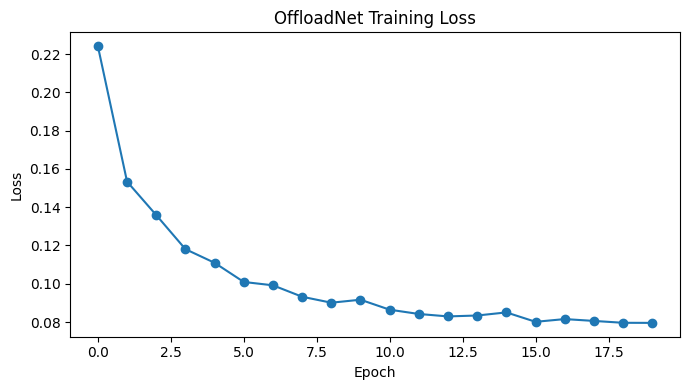

OffloadNet training complete.


In [ ]:
# OffloadNet — Definition + Training


class OffloadNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.layers(x)


# --- Handle class imbalance ---
class_counts  = np.bincount(y_train_np)
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float32
)
class_weights = class_weights / class_weights.sum()
print(f"Class weights → Edge: {class_weights[0]:.4f}  Cloud: {class_weights[1]:.4f}")

model      = OffloadNet(X_train.shape[1]).to(device)
criterion  = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer  = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_ds     = TensorDataset(X_train, y_train_t)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

# --- Training loop ---
EPOCHS = 20
model.train()
train_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg = epoch_loss / len(train_loader)
    train_losses.append(avg)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  Loss: {avg:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker='o')
plt.title("OffloadNet Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()
print("OffloadNet training complete.")

=== OffloadNet Classification Report ===
              precision    recall  f1-score   support

        Edge       1.00      0.97      0.99       366
       Cloud       0.87      1.00      0.93        69

    accuracy                           0.98       435
   macro avg       0.94      0.99      0.96       435
weighted avg       0.98      0.98      0.98       435



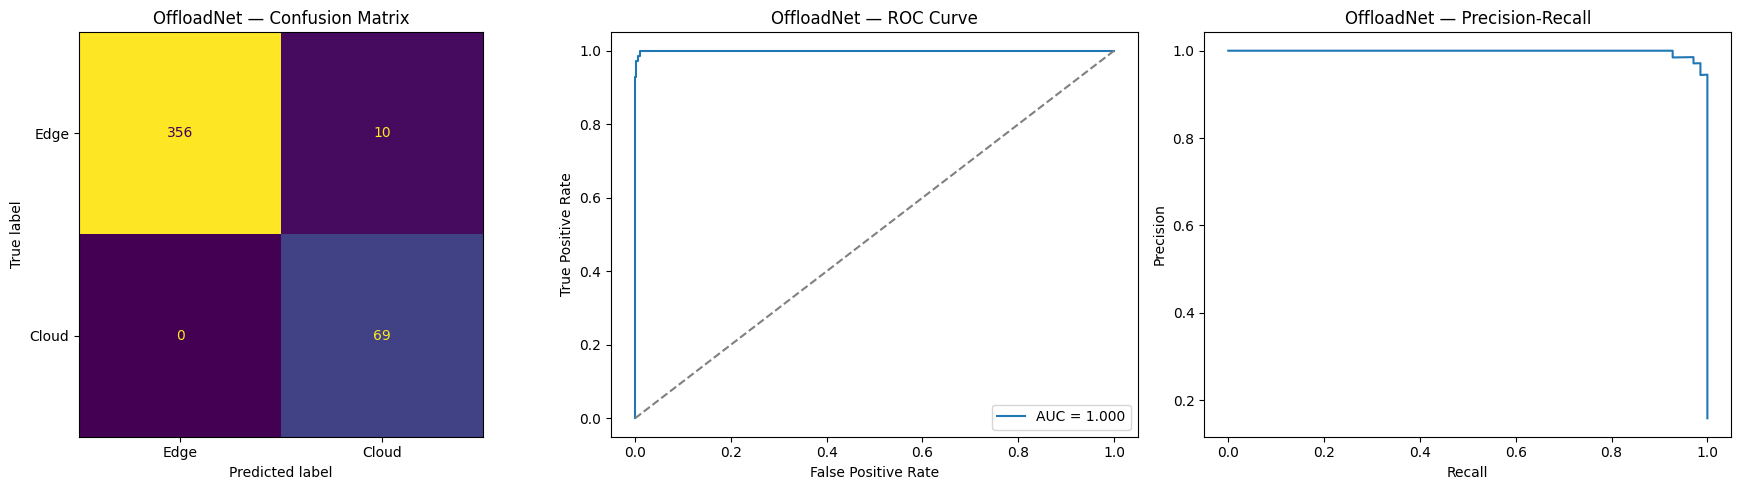

In [ ]:

# OffloadNet Evaluation

model.eval()

with torch.no_grad():
    logits      = model(X_test.to(device))
    pred_labels = torch.argmax(logits, dim=1).cpu().numpy()
    probs       = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

y_true = y_test_t.numpy()

print("=== OffloadNet Classification Report ===")
print(classification_report(y_true, pred_labels, target_names=["Edge", "Cloud"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm   = confusion_matrix(y_true, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=["Edge", "Cloud"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("OffloadNet — Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title("OffloadNet — ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_true, probs)
axes[2].plot(recall, precision)
axes[2].set_title("OffloadNet — Precision-Recall")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")

plt.tight_layout(); plt.show()

In [ ]:

# Federated DDQN — Setup


# ---------- Q-Network ----------
class QNetwork(nn.Module):
    def __init__(self, input_dim, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)


# ---------- Replay Buffer ----------
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state):
        self.buffer.append((state, action, reward, next_state))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns = zip(*batch)
        return (
            torch.stack(s),
            torch.tensor(a),
            torch.tensor(r, dtype=torch.float32),
            torch.stack(ns)
        )

    def __len__(self):
        return len(self.buffer)


# ---------- Federated Average (FIXED) ----------
def federated_average(models):
    global_model = deepcopy(models[0])
    global_state = global_model.state_dict()

    for key in global_state.keys():
        stacked            = torch.stack(
            [m.state_dict()[key].float() for m in models], dim=0
        )
        global_state[key]  = stacked.mean(dim=0)

    global_model.load_state_dict(global_state)   # ← crucial line
    return global_model


# ---------- Split data across clients ----------
def split_clients(X, num_clients=5):
    n = len(X) // num_clients
    return [X[i * n:(i + 1) * n] for i in range(num_clients)]


clients = split_clients(X_train, num_clients=5)
print(f"Clients          : {len(clients)}")
print(f"Samples/client   : {clients[0].shape[0]}")
print(f"Features/sample  : {clients[0].shape[1]}")

Clients          : 5
Samples/client   : 19913
Features/sample  : 13


In [ ]:

# Federated DDQN Training


# Hyper-parameters
GAMMA         = 0.95
EPSILON       = 1.0          # start fully exploratory
EPSILON_MIN   = 0.05
EPSILON_DECAY = 0.90         # per round
BATCH_SIZE    = 256
ROUNDS        = 15
MAX_STEPS     = 5000         # steps per client per round
TARGET_UPDATE = 200          # steps between target net sync

# Initialise global model
global_q      = QNetwork(X_train.shape[1]).to(device)
target_q      = deepcopy(global_q).to(device)

# Task rows aligned with training indices (for reward lookup)
train_tasks   = tasks[train_mask].reset_index(drop=True)

federated_losses  = []
federated_rewards = []

for rnd in range(ROUNDS):
    local_models  = []
    round_loss    = 0.0
    round_reward  = 0.0
    round_batches = 0
    round_steps   = 0

    for client_data in clients:
        local_model  = deepcopy(global_q).to(device)
        target_local = deepcopy(local_model).to(device)
        opt_local    = optim.Adam(local_model.parameters(), lr=0.0005)
        buf          = ReplayBuffer(8000)

        steps = min(len(client_data) - 1, MAX_STEPS)

        for i in range(steps):
            state      = client_data[i].to(device)
            next_state = client_data[i + 1].to(device)

            # Epsilon-greedy action
            if np.random.rand() < EPSILON:
                action = np.random.randint(0, 2)
            else:
                with torch.no_grad():
                    action = torch.argmax(local_model(state)).item()

            # ---- Reward (improved, normalized) ----
            row     = train_tasks.iloc[i]
            lat_e   = row["edge_latency"]
            lat_c   = row["cloud_latency"]
            latency = lat_e if action == 0 else lat_c

            best    = min(lat_e, lat_c)
            worst   = max(lat_e, lat_c)
            span    = worst - best + 1e-6
            lat_reward = (worst - latency) / span   # 1=best choice, 0=worst

            energy_norm = row["energy_required"] / (row["energy_required"] + 50.0)
            rejection   = row["rejected"]

            reward = (
                +3.0 * lat_reward
                - 2.0 * rejection
                - 0.3 * energy_norm
            )
            round_reward += reward
            round_steps  += 1

            buf.push(state, action, reward, next_state)

            # Training step
            if len(buf) > BATCH_SIZE:
                s_b, a_b, r_b, ns_b = buf.sample(BATCH_SIZE)
                s_b  = s_b.to(device);  ns_b = ns_b.to(device)
                a_b  = a_b.to(device);  r_b  = r_b.to(device)

                current_q = local_model(s_b).gather(
                    1, a_b.unsqueeze(1)
                ).squeeze()

                with torch.no_grad():
                    next_a  = torch.argmax(local_model(ns_b), dim=1)
                    next_q_val = target_local(ns_b).gather(
                        1, next_a.unsqueeze(1)
                    ).squeeze()
                    target_val = r_b + GAMMA * next_q_val

                loss = nn.MSELoss()(current_q, target_val)
                opt_local.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
                opt_local.step()

                round_loss   += loss.item()
                round_batches += 1

            if i % TARGET_UPDATE == 0:
                target_local.load_state_dict(local_model.state_dict())

        local_models.append(local_model.cpu())

    # Federated aggregation
    global_q = federated_average(local_models).to(device)
    target_q = deepcopy(global_q)

    EPSILON = max(EPSILON * EPSILON_DECAY, EPSILON_MIN)

    avg_loss   = round_loss   / max(round_batches, 1)
    avg_reward = round_reward / max(round_steps,   1)
    federated_losses.append(avg_loss)
    federated_rewards.append(avg_reward)

    print(f"Round {rnd+1:2d}/{ROUNDS}  |  "
          f"Loss: {avg_loss:.4f}  |  "
          f"AvgReward: {avg_reward:.4f}  |  "
          f"ε: {EPSILON:.3f}")

print("\nDDQN Training complete.")

Round  1/15  |  Loss: 1.1713  |  AvgReward: 1.2258  |  ε: 0.900
Round  2/15  |  Loss: 1.2230  |  AvgReward: 1.3195  |  ε: 0.810
Round  3/15  |  Loss: 1.1579  |  AvgReward: 1.3722  |  ε: 0.729
Round  4/15  |  Loss: 1.0528  |  AvgReward: 1.4548  |  ε: 0.656
Round  5/15  |  Loss: 1.0071  |  AvgReward: 1.4968  |  ε: 0.590
Round  6/15  |  Loss: 1.0038  |  AvgReward: 1.5849  |  ε: 0.531
Round  7/15  |  Loss: 0.9709  |  AvgReward: 1.6422  |  ε: 0.478
Round  8/15  |  Loss: 0.9609  |  AvgReward: 1.6849  |  ε: 0.430
Round  9/15  |  Loss: 0.9629  |  AvgReward: 1.7233  |  ε: 0.387
Round 10/15  |  Loss: 0.9555  |  AvgReward: 1.7595  |  ε: 0.349
Round 11/15  |  Loss: 0.9197  |  AvgReward: 1.8030  |  ε: 0.314
Round 12/15  |  Loss: 0.9101  |  AvgReward: 1.8496  |  ε: 0.282
Round 13/15  |  Loss: 0.8925  |  AvgReward: 1.8913  |  ε: 0.254
Round 14/15  |  Loss: 0.9138  |  AvgReward: 1.9083  |  ε: 0.229
Round 15/15  |  Loss: 0.9138  |  AvgReward: 1.9522  |  ε: 0.206

DDQN Training complete.


In [ ]:

# DDQN Evaluation

global_q.eval()

# --- Decision latency on test set ---
with torch.no_grad():
    t0        = time.time()
    q_out     = global_q(X_test.to(device))
    predicted = torch.argmax(q_out, dim=1).cpu()
    dt        = time.time() - t0

print(f"Decision overhead ({len(X_test)} samples): {dt*1000:.2f} ms")
print(f"Avg per sample                          : {dt/len(X_test)*1e6:.2f} µs")

# --- Latency comparison on random 5000 tasks ---
sample_tasks    = tasks.sample(5000, random_state=42)
model_latency   = []
baseline_latency= []
edge_count      = 0
cloud_count     = 0

global_q.eval()
for _, row in sample_tasks.iterrows():
    feat = build_features(row)
    feat = scaler.transform([feat])
    feat = torch.tensor(feat, dtype=torch.float32).to(device)

    with torch.no_grad():
        action = torch.argmax(global_q(feat)).item()

    if action == 0:
        model_latency.append(row["edge_latency"])
        edge_count += 1
    else:
        model_latency.append(row["cloud_latency"])
        cloud_count += 1

    baseline_latency.append(row["cloud_latency"])   # always-cloud baseline

model_latency    = np.array(model_latency)
baseline_latency = np.array(baseline_latency)

avg_m    = model_latency.mean()
avg_b    = baseline_latency.mean()
improve  = (avg_b - avg_m) / avg_b * 100
edge_r   = edge_count  / len(sample_tasks)
cloud_r  = cloud_count / len(sample_tasks)

print("\n===== DDQN PERFORMANCE =====")
print(f"Avg Latency  — DDQN        : {avg_m:.4f}")
print(f"Avg Latency  — Cloud Base  : {avg_b:.4f}")
print(f"Latency Improvement (%)    : {improve:.2f}%")
print(f"Edge Usage  (%)            : {edge_r*100:.2f}%")
print(f"Cloud Usage (%)            : {cloud_r*100:.2f}%")
print(f"Rejection Rate             : {tasks['rejected'].mean():.4f}")

# --- Plots ---
fig, axes

Decision overhead (435 samples): 0.94 ms
Avg per sample                          : 2.15 µs

===== DDQN PERFORMANCE =====
Avg Latency  — DDQN        : 48.1429
Avg Latency  — Cloud Base  : 52.3208
Latency Improvement (%)    : 7.99%
Edge Usage  (%)            : 86.64%
Cloud Usage (%)            : 13.36%
Rejection Rate             : 0.1186


(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'OffloadNet — Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
        <Axes: title={'center': 'OffloadNet — ROC Curve'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
        <Axes: title={'center': 'OffloadNet — Precision-Recall'}, xlabel='Recall', ylabel='Precision'>],
       dtype=object))

In [ ]:

# Generate Resource Allocation Targets


def generate_allocation_targets(task_row):
    t       = task_row["arrival_time"]
    edge_id = task_row["assigned_edge_id"]

    edge_rows = edge_state[
        (edge_state["timestep"] == t) &
        (edge_state["edge_id"]  == edge_id)
    ]
    if edge_rows.empty:
        return [0.5, 0.5]
    edge = edge_rows.iloc[0]

    cpu_share = task_row["cpu_cycles"]    / max(edge["edge_cpu_available"],    1e-6)
    mem_share = task_row["memory_req_mb"] / max(edge["edge_memory_available"], 1e-6)

    cpu_share = float(np.clip(cpu_share, 0.01, 1.0))
    mem_share = float(np.clip(mem_share, 0.01, 1.0))

    return [cpu_share, mem_share]


print("Generating allocation targets...")
allocation_targets = np.array(
    tasks.apply(generate_allocation_targets, axis=1).tolist()
)
print(f"Allocation targets shape : {allocation_targets.shape}")
print(f"CPU share  — mean: {allocation_targets[:,0].mean():.3f}  "
      f"std: {allocation_targets[:,0].std():.3f}")
print(f"Mem share  — mean: {allocation_targets[:,1].mean():.3f}  "
      f"std: {allocation_targets[:,1].std():.3f}")

Generating allocation targets...
Allocation targets shape : (100000, 2)
CPU share  — mean: 0.790  std: 0.319
Mem share  — mean: 0.627  std: 0.354


Edge allocation samples : 78286
Epoch  5/30  Loss: 0.0063
Epoch 10/30  Loss: 0.0029
Epoch 15/30  Loss: 0.0023
Epoch 20/30  Loss: 0.0019
Epoch 25/30  Loss: 0.0018
Epoch 30/30  Loss: 0.0017


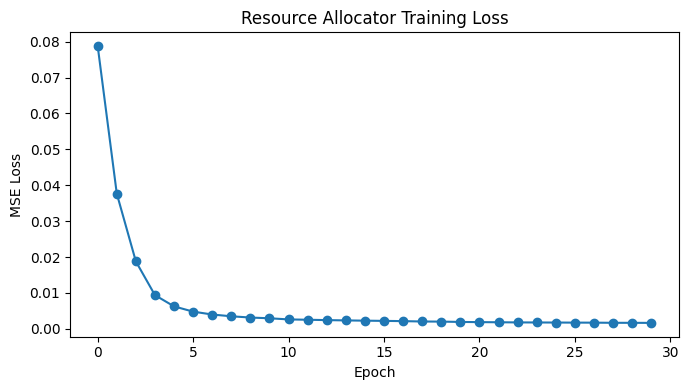

In [ ]:

#  ResourceAllocator — Training


# Only train allocator on tasks decided for edge execution
edge_mask    = tasks["offload_label"] == 0

X_alloc_raw  = features_raw[edge_mask]
y_alloc_np   = allocation_targets[edge_mask]
y_alloc_np   = np.clip(y_alloc_np, 0.0, 1.0)

# Separate scaler for allocator (do NOT reuse the offloading scaler)
scaler_alloc  = StandardScaler()
X_alloc_sc    = scaler_alloc.fit_transform(X_alloc_raw)

X_alloc = torch.tensor(X_alloc_sc, dtype=torch.float32)
y_alloc = torch.tensor(y_alloc_np, dtype=torch.float32)

print(f"Edge allocation samples : {X_alloc.shape[0]}")


class ResourceAllocator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Sigmoid()             # outputs in [0, 1]
        )

    def forward(self, x):
        return self.layers(x)


allocator      = ResourceAllocator(X_alloc.shape[1]).to(device)
crit_alloc     = nn.MSELoss()
opt_alloc      = optim.Adam(allocator.parameters(), lr=0.001, weight_decay=1e-4)
sched_alloc    = optim.lr_scheduler.StepLR(opt_alloc, step_size=10, gamma=0.5)

alloc_ds     = TensorDataset(X_alloc, y_alloc)
alloc_loader = DataLoader(alloc_ds, batch_size=512, shuffle=True)

ALLOC_EPOCHS = 30
alloc_losses = []

for epoch in range(ALLOC_EPOCHS):
    allocator.train()
    total = 0.0
    for xb, yb in alloc_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_alloc.zero_grad()
        loss = crit_alloc(allocator(xb), yb)
        loss.backward()
        opt_alloc.step()
        total += loss.item()
    sched_alloc.step()
    avg = total / len(alloc_loader)
    alloc_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{ALLOC_EPOCHS}  Loss: {avg:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(alloc_losses, marker='o')
plt.title("Resource Allocator Training Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.tight_layout(); plt.show()

Mean Absolute Allocation Error : 0.0186
CPU MAE : 0.0169
Mem MAE : 0.0203


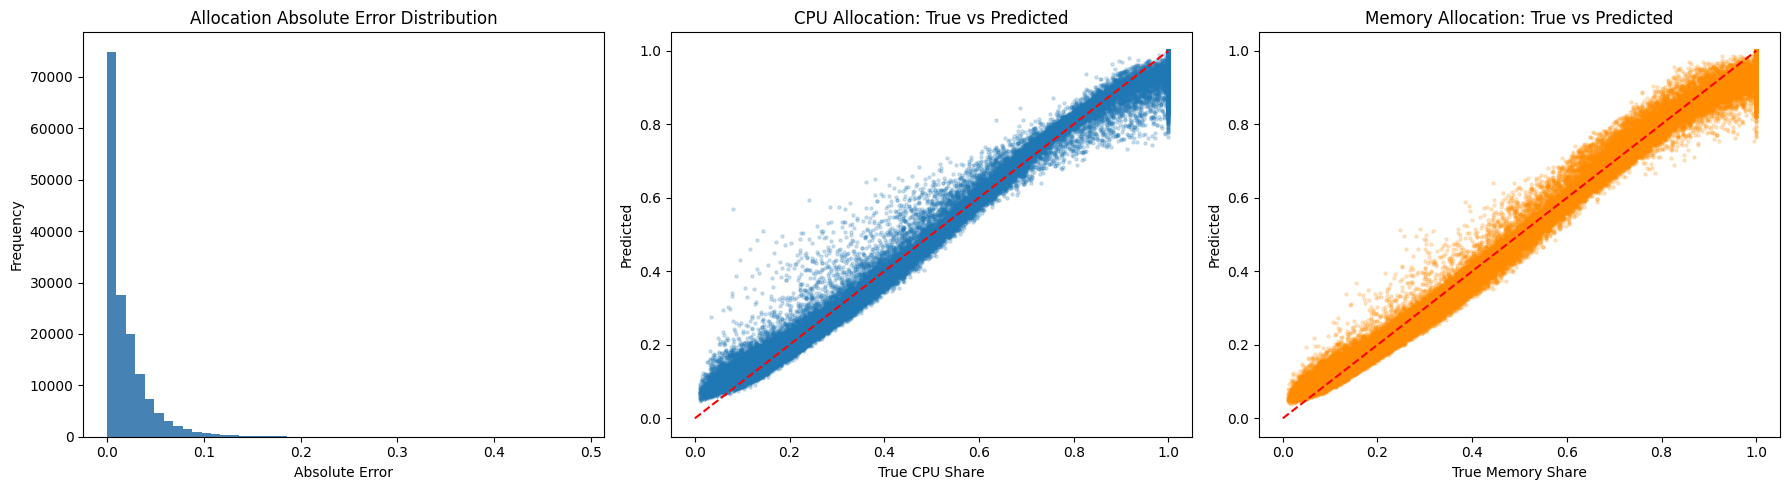

In [ ]:

# Resource Allocator Evaluation

allocator.eval()

with torch.no_grad():
    alloc_preds = allocator(X_alloc.to(device)).cpu()

errors = torch.abs(alloc_preds - y_alloc).numpy()
mae    = errors.mean()
print(f"Mean Absolute Allocation Error : {mae:.4f}")
print(f"CPU MAE : {errors[:,0].mean():.4f}")
print(f"Mem MAE : {errors[:,1].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error distribution
axes[0].hist(errors.flatten(), bins=50, color='steelblue')
axes[0].set_title("Allocation Absolute Error Distribution")
axes[0].set_xlabel("Absolute Error"); axes[0].set_ylabel("Frequency")

# CPU scatter
axes[1].scatter(y_alloc[:,0].numpy(), alloc_preds[:,0].numpy(),
                alpha=0.2, s=5)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_title("CPU Allocation: True vs Predicted")
axes[1].set_xlabel("True CPU Share"); axes[1].set_ylabel("Predicted")

# Memory scatter
axes[2].scatter(y_alloc[:,1].numpy(), alloc_preds[:,1].numpy(),
                alpha=0.2, s=5, color='darkorange')
axes[2].plot([0,1],[0,1],'r--')
axes[2].set_title("Memory Allocation: True vs Predicted")
axes[2].set_xlabel("True Memory Share"); axes[2].set_ylabel("Predicted")

plt.tight_layout(); plt.show()

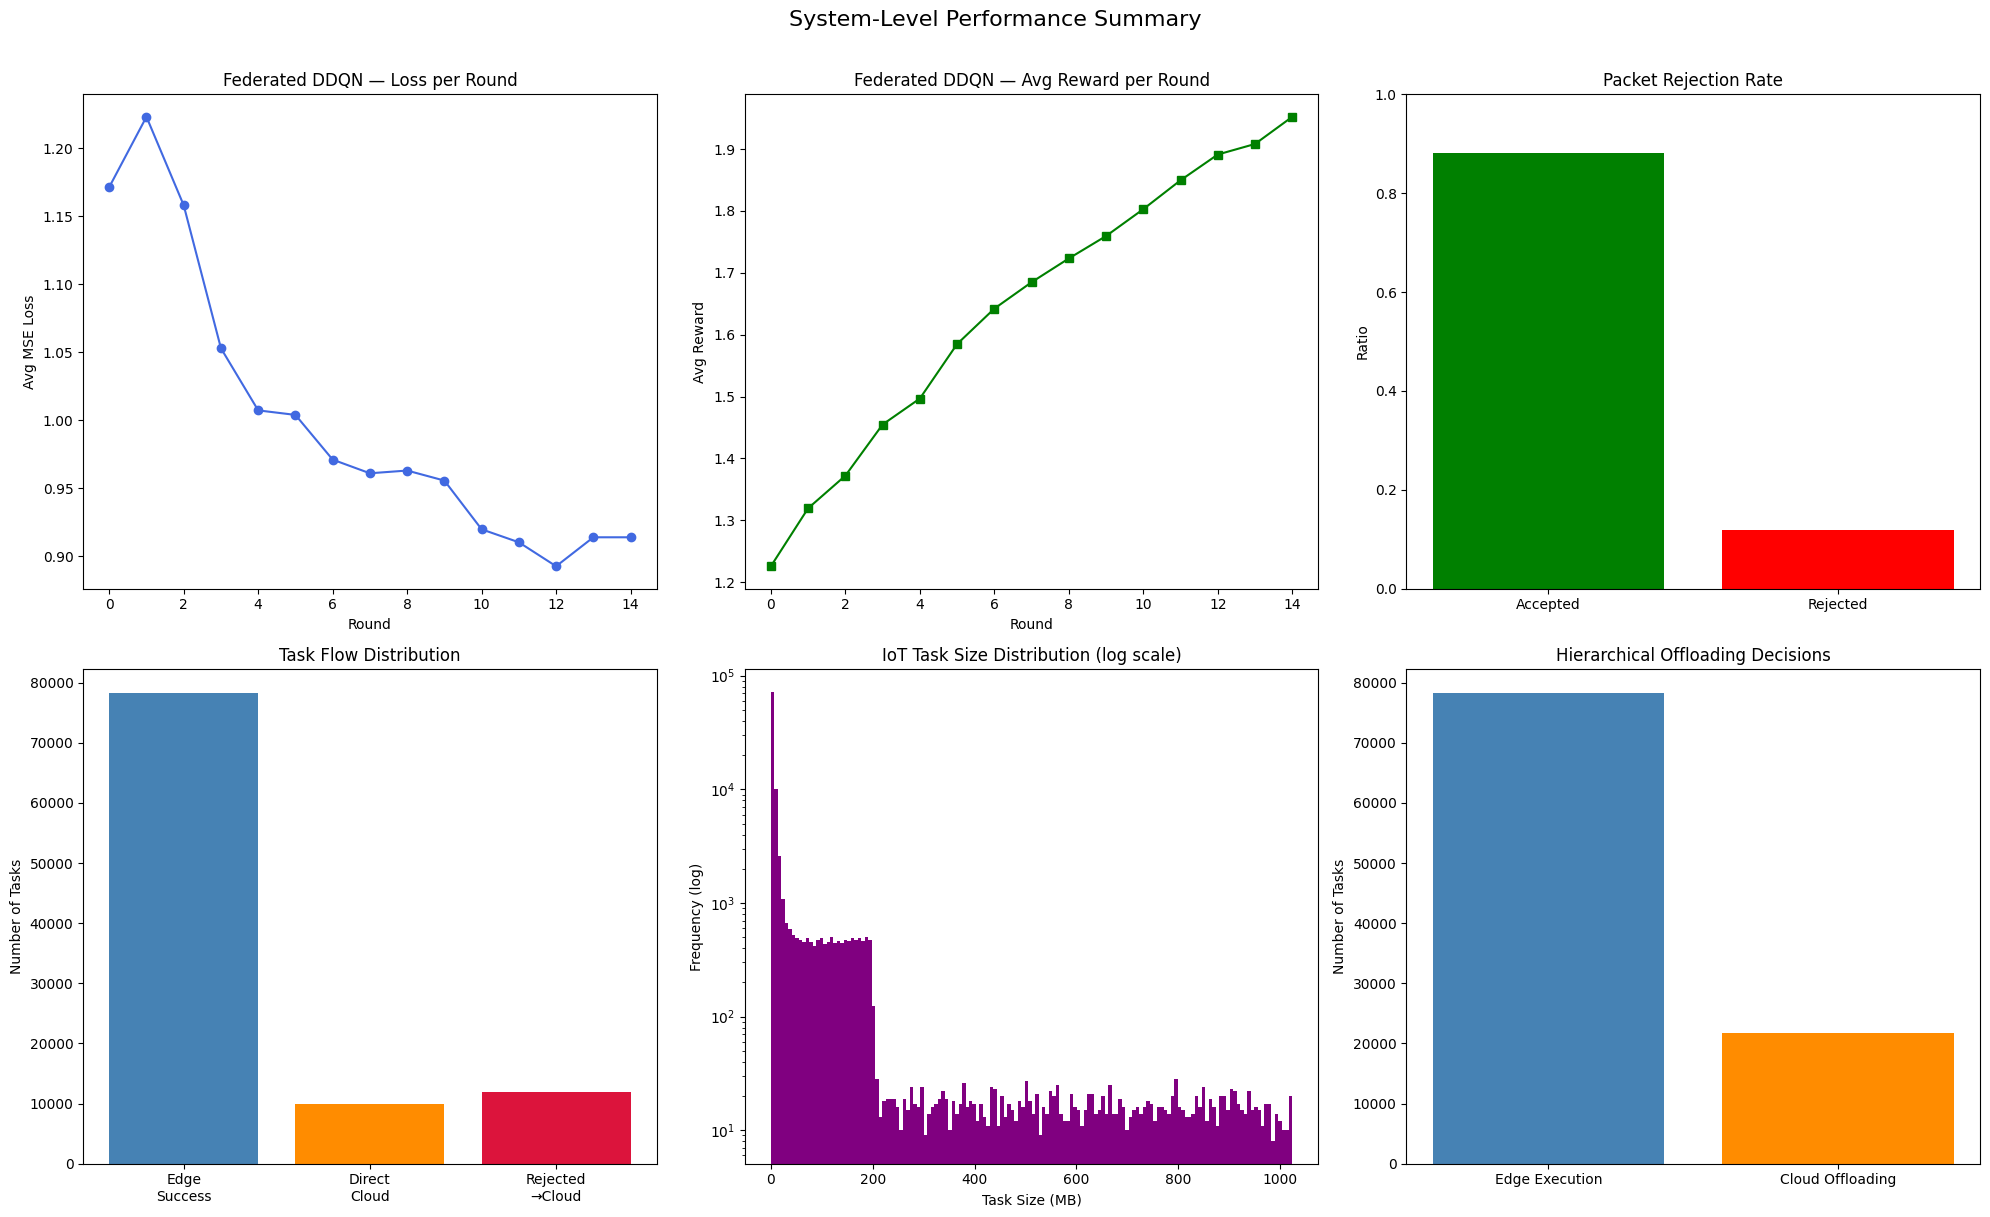

In [ ]:

# Convergence + System Summary


fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. DDQN loss convergence
axes[0,0].plot(federated_losses, marker='o', color='royalblue')
axes[0,0].set_title("Federated DDQN — Loss per Round")
axes[0,0].set_xlabel("Round"); axes[0,0].set_ylabel("Avg MSE Loss")

# 2. DDQN reward convergence
axes[0,1].plot(federated_rewards, marker='s', color='green')
axes[0,1].set_title("Federated DDQN — Avg Reward per Round")
axes[0,1].set_xlabel("Round"); axes[0,1].set_ylabel("Avg Reward")

# 3. Packet rejection rate
axes[0,2].bar(["Accepted", "Rejected"],
              [1 - tasks["rejected"].mean(), tasks["rejected"].mean()],
              color=["green", "red"])
axes[0,2].set_title("Packet Rejection Rate")
axes[0,2].set_ylabel("Ratio"); axes[0,2].set_ylim(0, 1)

# 4. Task flow (reallocation view)
flow = {
    "Edge\nSuccess":   ((tasks["offload_label"]==0)&(tasks["rejected"]==0)).sum(),
    "Direct\nCloud":   ((tasks["offload_label"]==1)&(tasks["rejected"]==0)).sum(),
    "Rejected\n→Cloud": (tasks["rejected"]==1).sum(),
}
axes[1,0].bar(flow.keys(), flow.values(),
              color=["steelblue","darkorange","crimson"])
axes[1,0].set_title("Task Flow Distribution")
axes[1,0].set_ylabel("Number of Tasks")

# 5. IoT task size distribution (heavy-tailed)
axes[1,1].hist(tasks["task_size_mb"], bins=150, color='purple')
axes[1,1].set_yscale("log")
axes[1,1].set_title("IoT Task Size Distribution (log scale)")
axes[1,1].set_xlabel("Task Size (MB)"); axes[1,1].set_ylabel("Frequency (log)")

# 6. Hierarchical offloading decision count
decision_counts = tasks["offload_label"].value_counts()
axes[1,2].bar(["Edge Execution", "Cloud Offloading"],
              [decision_counts.get(0,0), decision_counts.get(1,0)],
              color=["steelblue","darkorange"])
axes[1,2].set_title("Hierarchical Offloading Decisions")
axes[1,2].set_ylabel("Number of Tasks")

plt.suptitle("System-Level Performance Summary", fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

In [ ]:

# Final Summary Table

from sklearn.metrics import accuracy_score, f1_score

# OffloadNet metrics
model.eval()
with torch.no_grad():
    logits_test = model(X_test.to(device))
    preds_net   = torch.argmax(logits_test, dim=1).cpu().numpy()
    probs_net   = torch.softmax(logits_test, dim=1)[:,1].cpu().numpy()

acc_net = accuracy_score(y_test_t.numpy(), preds_net)
f1_net  = f1_score(y_test_t.numpy(), preds_net, average='weighted')
fpr_, tpr_, _ = roc_curve(y_test_t.numpy(), probs_net)
auc_net = auc(fpr_, tpr_)

# DDQN metrics
avg_m   = model_latency.mean()
avg_b   = baseline_latency.mean()
improve = (avg_b - avg_m) / avg_b * 100

# Allocator metric
with torch.no_grad():
    ap    = allocator(X_alloc.to(device)).cpu()
    mae_a = torch.mean(torch.abs(ap - y_alloc)).item()

print("=" * 52)
print(f"{'METRIC':<35} {'VALUE':>15}")
print("=" * 52)
print(f"{'[OffloadNet] Accuracy':<35} {acc_net*100:>14.2f}%")
print(f"{'[OffloadNet] Weighted F1':<35} {f1_net:>15.4f}")
print(f"{'[OffloadNet] ROC-AUC':<35} {auc_net:>15.4f}")
print("-" * 52)
print(f"{'[DDQN] Avg Latency':<35} {avg_m:>15.4f}")
print(f"{'[DDQN] Baseline Latency':<35} {avg_b:>15.4f}")
print(f"{'[DDQN] Latency Improvement':<35} {improve:>14.2f}%")
print(f"{'[DDQN] Edge Usage':<35} {edge_r*100:>14.2f}%")
print(f"{'[DDQN] Cloud Usage':<35} {cloud_r*100:>14.2f}%")
print("-" * 52)
print(f"{'[Allocator] Mean Abs Error':<35} {mae_a:>15.4f}")
print(f"{'[System]  Rejection Rate':<35} {tasks['rejected'].mean():>15.4f}")
print("=" * 52)

METRIC                                        VALUE
[OffloadNet] Accuracy                        97.70%
[OffloadNet] Weighted F1                     0.9776
[OffloadNet] ROC-AUC                         0.9996
----------------------------------------------------
[DDQN] Avg Latency                          48.1429
[DDQN] Baseline Latency                     52.3208
[DDQN] Latency Improvement                    7.99%
[DDQN] Edge Usage                            86.64%
[DDQN] Cloud Usage                           13.36%
----------------------------------------------------
[Allocator] Mean Abs Error                   0.0186
[System]  Rejection Rate                     0.1186
